In [13]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

In [14]:

cluster_folders = {
    "gassing": Path("Data/Cluster_0 (gassing)"),
    "cracking": Path("Data/Cluster_1 (cracking)"),
    "mixed": Path("Data/Cluster_2 (mix undecided)")
}

cluster_data = {
    cluster: {
        csv_file.stem: pd.read_csv(csv_file)
        for csv_file in sorted(folder.glob("*.csv"))
    }
    for cluster, folder in cluster_folders.items()
}

In [15]:
time_threshold = 0.00005
noise_data = {}
signal_data = {}

for cluster_name, file_data in cluster_data.items():
    noise_data[cluster_name] = {}
    signal_data[cluster_name] = {}

    for file_name, dataframe in file_data.items():
        noise_mask = dataframe["Time (s)"] < time_threshold
        signal_mask = dataframe["Time (s)"] >= time_threshold
        noise_data[cluster_name][file_name] = dataframe.loc[noise_mask].copy()
        signal_data[cluster_name][file_name] = dataframe.loc[signal_mask].copy()

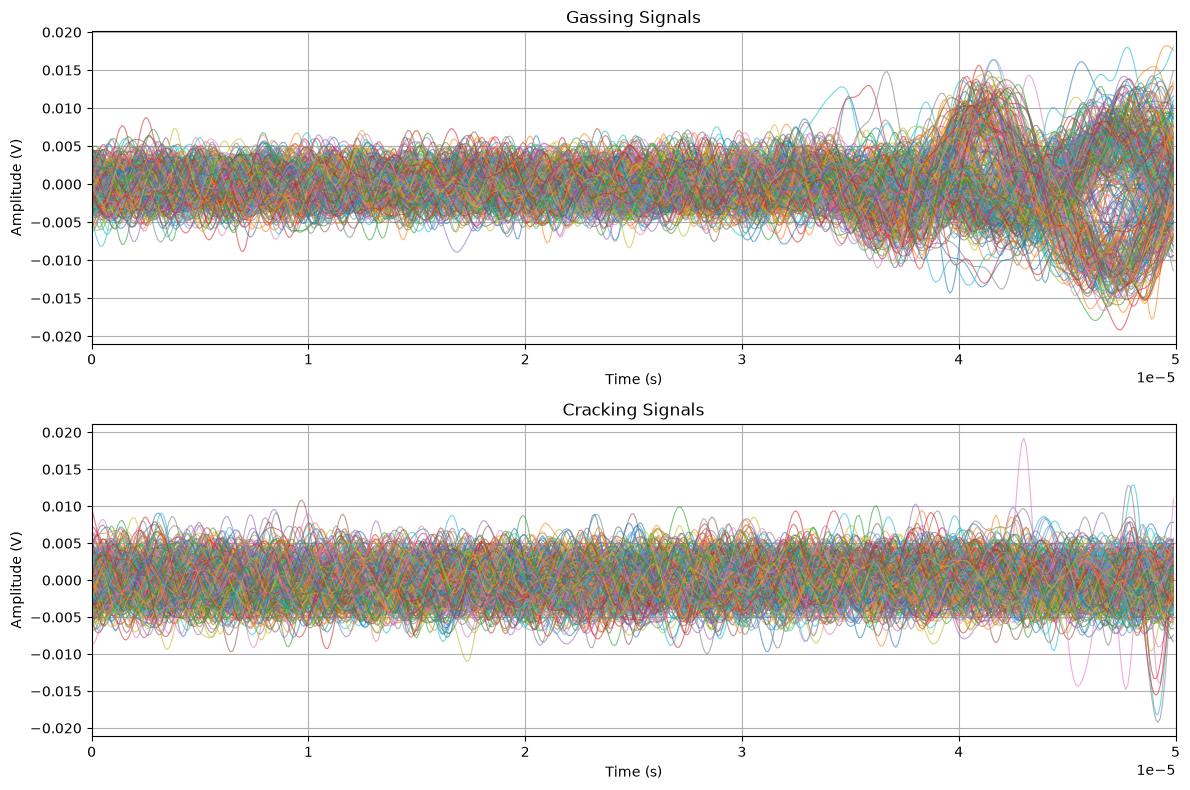

In [16]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

for key in noise_data["gassing"]:
    noise_data["gassing"][key].plot(
        x="Time (s)",
        y="Amplitude (V)",
        ax=ax[0],
        legend=False,
        alpha=0.6,      
        linewidth=0.8
    )

for key in noise_data["cracking"]:
    noise_data["cracking"][key].plot(
        x="Time (s)",
        y="Amplitude (V)",
        ax=ax[1],
        legend=False,
        alpha=0.6,
        linewidth=0.8
    )

ax[0].set_xlim(0.0000, 0.00005)
ax[0].set_title("Gassing Signals")
ax[0].set_ylabel("Amplitude (V)")
ax[0].grid(True)

ax[1].set_xlim(0.0000, 0.00005)
ax[1].set_title("Cracking Signals")
ax[1].set_ylabel("Amplitude (V)")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [17]:
all_noise =  noise_data["cracking"]#| noise_data["mixed"]

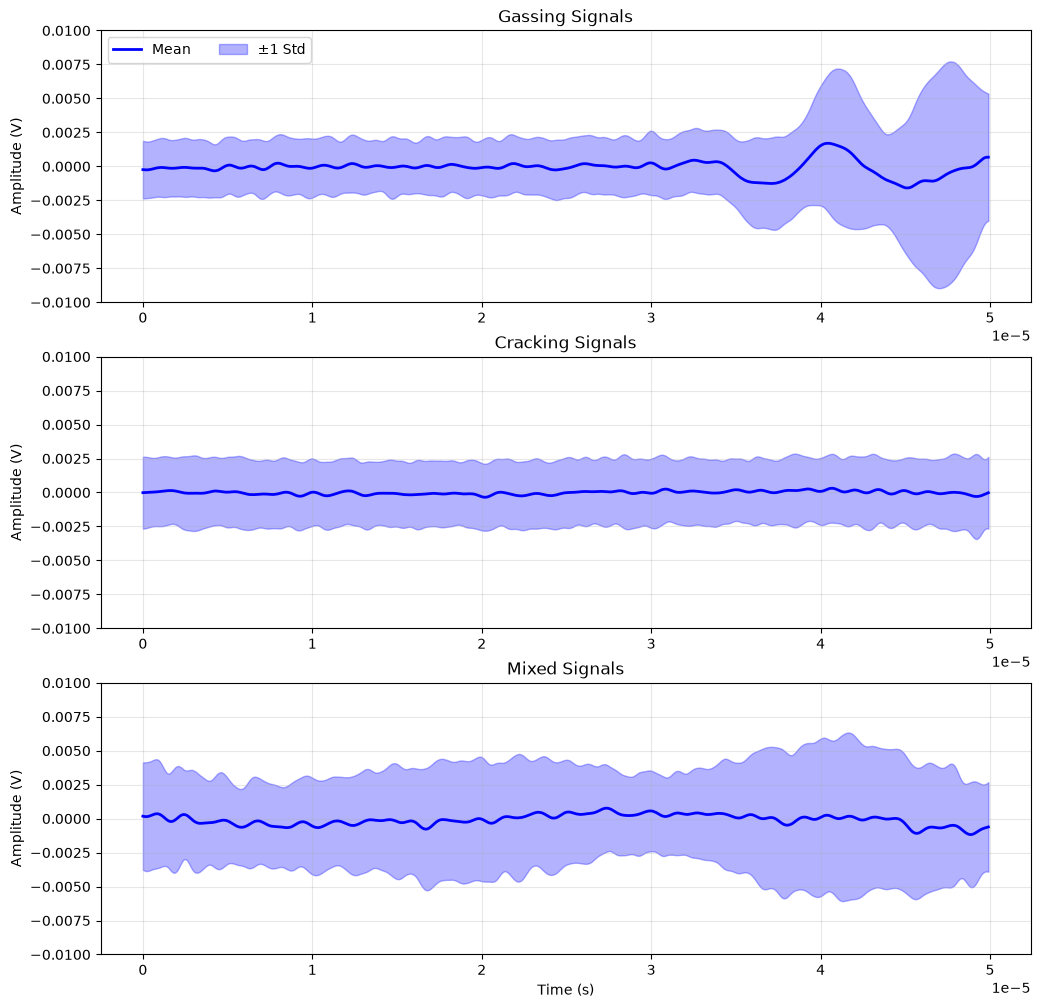

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(12, 12))
class_lst = ["gassing", "cracking", "mixed"]
for i, c in enumerate(class_lst):
    signals = np.array([
    df["Amplitude (V)"].values
    for df in noise_data[c].values()
    ])

    time = next(iter(noise_data[c].values()))["Time (s)"].values

    mean_signal = signals.mean(axis=0)
    std_signal = signals.std(axis=0)

    # Plot
    # plt.figure(figsize=(12, 4))

    ax[i].plot(
    time,
    mean_signal,
    color="blue",
    linewidth=2,
    label="Mean"
    )

    ax[i].fill_between(
    time,
    mean_signal - std_signal,
    mean_signal + std_signal,
    color="blue",
    alpha=0.3,
    label="±1 Std"
    )
    percentiles = np.array(range(70, 100, 5))
    colors = plt.cm.viridis(np.linspace(0, 1, len(percentiles)))
    first_crossing_time_lst = []
    # for p, color in zip(percentiles, colors):

    #     threshold = np.percentile(std_signal, p)

    #     idx = np.where(std_signal > threshold)[0]

    #     if len(idx) > 0:
    #         first_crossing_time = time[idx[0]]
    #         first_crossing_time_lst.append(first_crossing_time) 
    #     else:
    #         first_crossing_time_lst.append(0) 
    #     ax[i].axvline(
    #     first_crossing_time,
    #     color=color,
    #     linestyle="--",
    #     alpha=0.8,
    #     label=f"{p}%"
    #     )
    first_crossing_time_lst = np.array(first_crossing_time_lst)
    ax[i].set_ylabel("Amplitude (V)")
    ax[i].set_title(c.capitalize() + " Signals")
    ax[i].grid(alpha=0.3)
    ax[i].set_ylim(-0.01, 0.01)
ax[-1].set_xlabel("Time (s)")
ax[0].legend(ncol=4)
plt.show()

In [19]:
all_noise_filtered = {}
for key in all_noise.keys():
    all_noise_filtered[key] = all_noise[key]#[all_noise[key]["Time (s)"]<=first_crossing_time_lst[percentiles==75][0]]

In [20]:
def run_fft_df(input_df, N_target=362):
    time = input_df['Time (s)'].values
    amplitude = input_df['Amplitude (V)'].values[:N_target]
    
    N = len(amplitude)
    dt = time[1] - time[0] 
    
    amp_detrend = amplitude 
    
    fft_vals = np.fft.rfft(amp_detrend)
    freqs = np.fft.rfftfreq(N, d=dt) / 1e3 # kHz 변환
    magnitude = np.abs(fft_vals) / N

    if N % 2 == 0:
        magnitude[1:-1] *= 2 
    else:
        magnitude[1:] *= 2   
    return freqs / 1e3, magnitude

def run_fft(input_dict, N_target=362):
    freq_lst = []
    magnitude_lst = []
    for key, df in input_dict.items():
            freqs, magnitude = run_fft_df(df, N_target)
            freq_lst.append(freqs)
            magnitude_lst.append(magnitude)
    return np.array(freq_lst) / 1e3, np.array(magnitude_lst)

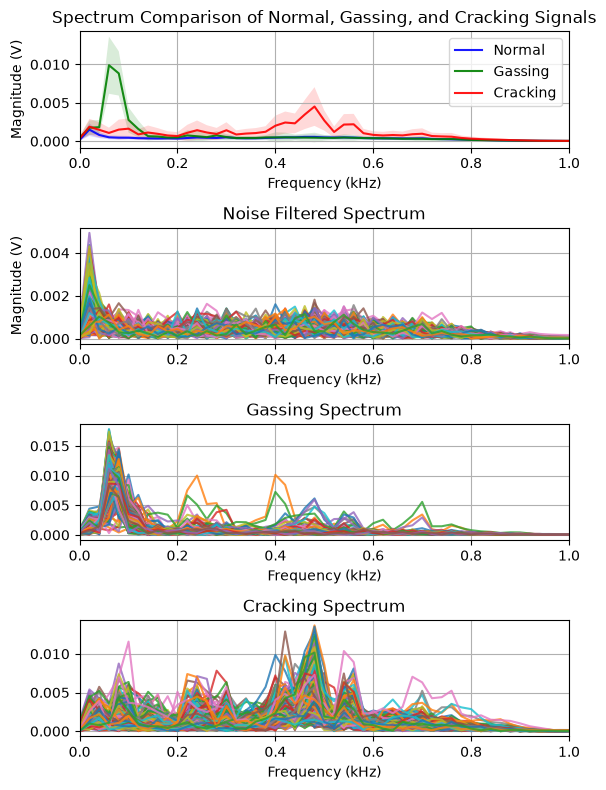

In [41]:
fig, ax = plt.subplots(4,1, figsize=(6, 8))

N = 500
# 2. noise
noise_freq_lst, noise_magnitude_lst = [], []
gassing_freq_lst, gassing_magnitude_lst = [], []
cracking_freq_lst, cracking_magnitude_lst = [], []

for key in all_noise_filtered:
    noise_freqs, noise_magnitude = run_fft_df(all_noise_filtered[key], N_target=N)
    noise_freq_lst.append(noise_freqs)
    noise_magnitude_lst.append(noise_magnitude)
for key in signal_data['gassing']:
    gassing_freqs, gassing_magnitude = run_fft_df(signal_data['gassing'][key], N_target=N)
    gassing_freq_lst.append(gassing_freqs)
    gassing_magnitude_lst.append(gassing_magnitude)
for key in signal_data['cracking']:
    cracking_freqs, cracking_magnitude = run_fft_df(signal_data['cracking'][key], N_target=N)
    cracking_freq_lst.append(cracking_freqs)
    cracking_magnitude_lst.append(cracking_magnitude)


freq_normal = noise_freq_lst[0]
freq_gassing = gassing_freq_lst[0]
freq_cracking = cracking_freq_lst[0]

noise_magnitude_lst = np.array(noise_magnitude_lst)
gassing_magnitude_lst = np.array(gassing_magnitude_lst)
cracking_magnitude_lst = np.array(cracking_magnitude_lst)

mean_normal = noise_magnitude_lst.mean(axis=0)
std_normal = noise_magnitude_lst.std(axis=0)

mean_gassing = gassing_magnitude_lst.mean(axis=0)
std_gassing = gassing_magnitude_lst.std(axis=0)

mean_cracking = cracking_magnitude_lst.mean(axis=0)
std_cracking = cracking_magnitude_lst.std(axis=0)

ax[0].plot(freq_normal, mean_normal, color='blue', alpha=0.9, label='Normal', linewidth=1.5)
ax[0].fill_between(freq_normal, mean_normal - std_normal, mean_normal + std_normal, 
                    color='blue', alpha=0.15, edgecolor='none')

# 4. Gassing (Green) 
ax[0].plot(freq_gassing, mean_gassing, color='green', alpha=0.9, label='Gassing', linewidth=1.5)
ax[0].fill_between(freq_gassing, mean_gassing - std_gassing, mean_gassing + std_gassing, 
                    color='green', alpha=0.15, edgecolor='none')

# 5. Cracking (Red) 
ax[0].plot(freq_cracking, mean_cracking, color='red', alpha=0.9, label='Cracking', linewidth=1.5)
ax[0].fill_between(freq_cracking, mean_cracking - std_cracking, mean_cracking + std_cracking, 
                    color='red', alpha=0.15, edgecolor='none')

# 6. 레이아웃 및 축 설정
ax[0].set_xlim(0, 1)
ax[0].set_title('Spectrum Comparison of Normal, Gassing, and Cracking Signals')
ax[0].set_xlabel('Frequency (kHz)')
ax[0].set_ylabel('Magnitude (V)')
ax[0].grid(True)
ax[0].legend()


ax[1].plot(freq_normal, noise_magnitude_lst.T, alpha=0.8)
ax[1].set_xlim(0, 1)
ax[1].set_title('Noise Filtered Spectrum')
ax[1].set_xlabel('Frequency (kHz)')
ax[1].set_ylabel('Magnitude (V)')
ax[1].grid(True)

# 3. gassing
ax[2].plot(freq_gassing, gassing_magnitude_lst.T, alpha=0.8)
ax[2].set_xlim(0, 1)
ax[2].set_title('Gassing Spectrum')
ax[2].set_xlabel('Frequency (kHz)')
ax[2].grid(True)

# 4.  cracking
ax[3].plot(freq_cracking, cracking_magnitude_lst.T, alpha=0.8)
ax[3].set_xlim(0, 1)
ax[3].set_title('Cracking Spectrum')
ax[3].set_xlabel('Frequency (kHz)')
ax[3].grid(True)

plt.tight_layout()
plt.show()

In [22]:
X = np.vstack([noise_magnitude_lst, gassing_magnitude_lst, cracking_magnitude_lst])
y = np.array([0]*len(noise_magnitude_lst) + [1]*len(gassing_magnitude_lst) + [2]*len(cracking_magnitude_lst))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
print(f"Training set size: {X_train.shape[0]}")
print(f"Testset size: {X_test.shape[0]}")




Training set size: 1009
Testset size: 113


In [24]:
model=GaussianNB()
model.fit(X_train, y_train)
accuracy = model.score(X_train, y_train) 
print("Training Accuracy:", accuracy)
accuracy = model.score(X_test, y_test)
print("Test Accuracy:", accuracy)

Training Accuracy: 0.9355797819623389
Test Accuracy: 0.8938053097345132


In [25]:
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y_train)),
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)
xgb_model.fit(X_train, y_train)

xgb_train_accuracy = xgb_model.score(X_train, y_train)
xgb_test_accuracy = xgb_model.score(X_test, y_test)
print("XGBoost training accuracy:", xgb_train_accuracy)
print("XGBoost test accuracy:", xgb_test_accuracy)
print(classification_report(
    y_test,
    xgb_model.predict(X_test),
    target_names=["Noise", "Gassing", "Cracking"],
    zero_division=0,
))

XGBoost training accuracy: 1.0
XGBoost test accuracy: 0.9823008849557522
              precision    recall  f1-score   support

       Noise       0.97      1.00      0.99        38
     Gassing       1.00      0.97      0.99        38
    Cracking       0.97      0.97      0.97        37

    accuracy                           0.98       113
   macro avg       0.98      0.98      0.98       113
weighted avg       0.98      0.98      0.98       113



In [26]:
def fft_with_stride(cluster_data, N_target=N, stride=N):
    magnitude_input = {}
    for key in cluster_data["mixed"]:
        magnitude_input[key] = []
        df = cluster_data["mixed"][key]
        for i in range(0, len(df) - N + 1, stride):
            window_df = df.iloc[i : i + N]
            freq, magnitude = run_fft_df(window_df, N_target=N)
            if len(magnitude) > model.n_features_in_:
                curr_mag = magnitude[:model.n_features_in_]
            else:
                curr_mag = magnitude
                
            magnitude_input[key].append(curr_mag)

    return magnitude_input

magnitude_input = fft_with_stride(cluster_data, N_target=N, stride=N)

In [29]:
result_dict = {}
prob_dict = {}
model_lst = ["GaussNB", "XGBoost"]
for m in model_lst:
    result_dict[m] = {}
    prob_dict[m] = {}
for key in magnitude_input:
    for m in model_lst:
        result_dict[m][key] = []
        prob_dict[m][key] = []    
    for spectrum in magnitude_input[key]:                    
        prob = model.predict_proba(np.array(spectrum).reshape(1, -1))[0]
        result_dict['GaussNB'][key].append(prob)
        prob_dict['GaussNB'][key].append(prob)

        xgb_prob = xgb_model.predict_proba(np.array(spectrum).reshape(1, -1))[0]
        result_dict['XGBoost'][key].append(xgb_prob)
        prob_dict['XGBoost'][key].append(xgb_prob)
        
    result_dict['GaussNB'][key] = np.array(result_dict['GaussNB'][key]).argmax(axis=1)
    result_dict['XGBoost'][key] = np.array(result_dict['XGBoost'][key]).argmax(axis=1)

In [39]:
def plot_classification_regions(key, magnitude_input, result_dict, cluster_data, N):
    fig, ax = plt.subplots(2, 1, figsize=(8, 4))
    df = cluster_data["mixed"][key]
    time_arr = df['Time (s)'].values
    amp_arr = df['Amplitude (V)'].values

    ax[0].plot(time_arr, amp_arr, color='black', linewidth=0.8, alpha=0.7, label='AE Signal')

    color_map = {0: 'green', 1: 'orange', 2: 'red'}
    label_map = {0: 'Normal (0)', 1: 'Gassing (1)', 2: 'Cracking (2)'}
    used_labels = set()
    for idx, cls_id in enumerate(result_dict):
        i = idx * N  
        
        t_start = time_arr[i]
        t_end = time_arr[i + N - 1] if (i + N - 1) < len(time_arr) else time_arr[-1]
        
        color = color_map.get(cls_id, 'gray')
        label = label_map.get(cls_id, f'Class {cls_id}') if cls_id not in used_labels else None
        
        ax[0].axvspan(t_start, t_end, color=color, alpha=0.25, edgecolor='none', label=label)
        used_labels.add(cls_id)

    ax[0].set_xlim(0.0, 0.00005*6)
    ax[0].set_xlabel('Time (s)', fontsize=12)
    ax[0].set_ylabel('Amplitude (V)', fontsize=12)
    ax[0].set_title(f'Classification Regions (Window = {N} and Strid = {N}) for {key}', fontsize=14)
    ax[0].grid(True, linestyle='--', alpha=0.5)
    ax[0].legend(loc='upper right')


    for i, mag in enumerate(magnitude_input[key]):
        ax[1].plot(freq_normal, mag, alpha=0.8, label = f'Magnitude {i+1}')
    ax[1].set_xlim(0, 1)
    ax[1].legend()
    ax[1].grid(True, linestyle='--', alpha=0.5)
    plt.show()


/scratch/ipykernel_96961/2207827908.py:21: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax[0].axvspan(t_start, t_end, color=color, alpha=0.25, edgecolor='none', label=label)


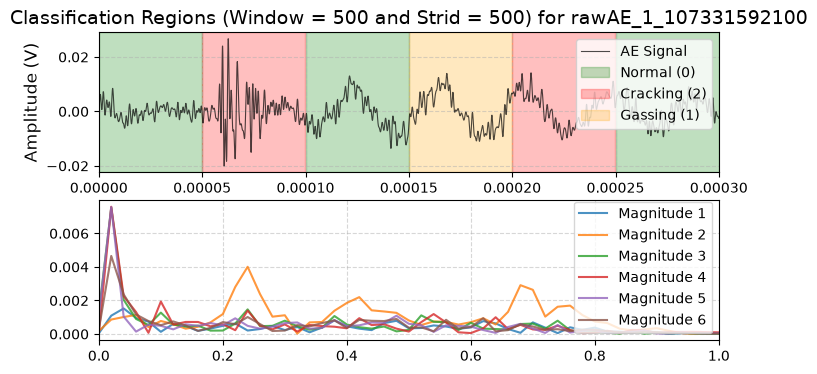

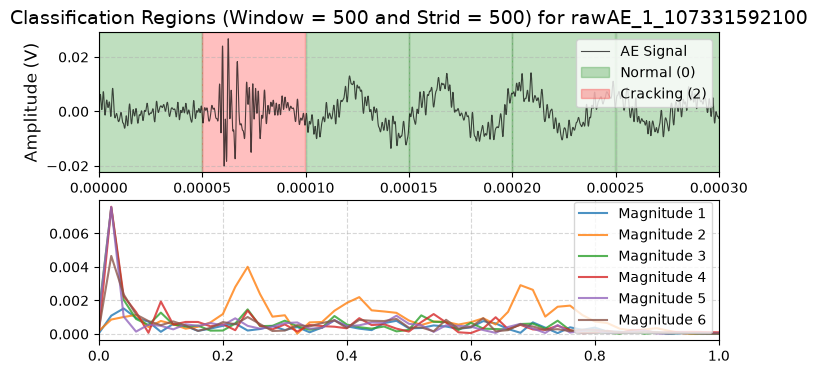

In [40]:

key = list(magnitude_input.keys())[5]
m = 'GaussNB'
plot_classification_regions(key, magnitude_input, result_dict['GaussNB'][key], cluster_data, N)
m = 'XGBoost'
plot_classification_regions(key, magnitude_input, result_dict['XGBoost'][key], cluster_data, N)

## Gaussian AR(p) maximum-likelihood classifier

This generative baseline treats each labeled waveform as a separate sequence. For each class, it fits a shared AR(p) process by maximizing the pooled conditional Gaussian likelihood, then classifies held-out sequences by their per-sample log likelihood. This is an ARMA(p, 0) model and requires no additional packages.

In [42]:
from sklearn.metrics import accuracy_score, classification_report

AR_ORDER = 8
AR_CLASS_NAMES = ["Normal", "Gassing", "Cracking"]
AR_CLASS_SOURCES = [all_noise_filtered, signal_data["gassing"], signal_data["cracking"]]


def conditional_ar_design(sequence, order):
    sequence = np.asarray(sequence, dtype=float)
    target = sequence[order:]
    lagged = [sequence[order - lag : len(sequence) - lag] for lag in range(1, order + 1)]
    design = np.column_stack([np.ones(len(target)), *lagged])
    return design, target


def fit_gaussian_ar_mle(sequences, order):
    designs_and_targets = [conditional_ar_design(sequence, order) for sequence in sequences]
    design = np.vstack([item[0] for item in designs_and_targets])
    target = np.concatenate([item[1] for item in designs_and_targets])

    coefficients, _, _, _ = np.linalg.lstsq(design, target, rcond=None)
    residual = target - design @ coefficients
    innovation_variance = max(np.mean(residual**2), np.finfo(float).eps)
    return coefficients, innovation_variance


def gaussian_ar_log_likelihood(sequence, coefficients, innovation_variance, order):
    design, target = conditional_ar_design(sequence, order)
    residual = target - design @ coefficients
    mean_squared_error = np.mean(residual**2)
    return -0.5 * (np.log(2 * np.pi * innovation_variance) + mean_squared_error / innovation_variance)


ar_sequences = []
ar_labels = []
ar_file_keys = []
for class_id, class_sources in enumerate(AR_CLASS_SOURCES):
    for file_key, dataframe in class_sources.items():
        sequence = dataframe["Amplitude (V)"].to_numpy(dtype=float)[:N]
        if len(sequence) > AR_ORDER and np.isfinite(sequence).all():
            ar_sequences.append(sequence)
            ar_labels.append(class_id)
            ar_file_keys.append(file_key)

ar_labels = np.asarray(ar_labels)
ar_indices = np.arange(len(ar_sequences))
ar_train_idx, ar_test_idx = train_test_split(
    ar_indices,
    test_size=0.25,
    random_state=42,
    stratify=ar_labels,
)
ar_train_sequences = [ar_sequences[index] for index in ar_train_idx]
ar_test_sequences = [ar_sequences[index] for index in ar_test_idx]
ar_y_train = ar_labels[ar_train_idx]
ar_y_test = ar_labels[ar_test_idx]

ar_class_models = {}
for class_id, class_name in enumerate(AR_CLASS_NAMES):
    class_train_sequences = [
        sequence for sequence, label in zip(ar_train_sequences, ar_y_train)
        if label == class_id
    ]
    ar_class_models[class_id] = fit_gaussian_ar_mle(class_train_sequences, AR_ORDER)

ar_log_likelihoods = np.array([
    [
        gaussian_ar_log_likelihood(sequence, *ar_class_models[class_id], AR_ORDER)
        for class_id in range(len(AR_CLASS_NAMES))
    ]
    for sequence in ar_test_sequences
])
ar_y_pred = ar_log_likelihoods.argmax(axis=1)

print(f"AR({AR_ORDER}) / ARMA({AR_ORDER}, 0) file-level split")
print(f"Training sequences: {len(ar_train_idx)}; test sequences: {len(ar_test_idx)}")
print(f"Test accuracy: {accuracy_score(ar_y_test, ar_y_pred):.3f}")
print(classification_report(
    ar_y_test,
    ar_y_pred,
    labels=np.arange(len(AR_CLASS_NAMES)),
    target_names=AR_CLASS_NAMES,
    zero_division=0,
))
for class_id, class_name in enumerate(AR_CLASS_NAMES):
    coefficients, innovation_variance = ar_class_models[class_id]
    print(f"{class_name}: intercept={coefficients[0]:.6g}, AR coefficients={coefficients[1:]}, "
          f"innovation variance={innovation_variance:.6g}")

AR(8) / ARMA(8, 0) file-level split
Training sequences: 841; test sequences: 281
Test accuracy: 0.979
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98        94
     Gassing       0.96      0.99      0.97        94
    Cracking       0.98      0.99      0.98        93

    accuracy                           0.98       281
   macro avg       0.98      0.98      0.98       281
weighted avg       0.98      0.98      0.98       281

Normal: intercept=-1.63555e-07, AR coefficients=[ 2.23519551 -0.88698817 -0.90727096  0.07135758  0.58753035  0.21852738
 -0.40325773  0.0754527 ], innovation variance=5.60043e-09
Gassing: intercept=3.93873e-07, AR coefficients=[ 2.39033804 -1.08884584 -0.96485331  0.16851056  0.66137782  0.20809635
 -0.47849026  0.10251378], innovation variance=6.57145e-09
Cracking: intercept=-1.13385e-06, AR coefficients=[ 2.72909057 -1.75157769 -1.00921295  0.62061266  0.97540718 -0.05187523
 -0.94327295  0.4263371 ], innovat